# EDA of ATO dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

Here I'll do Stratified Sampling first - get all the isATO = 1

In [2]:
# filename = "../data/ato.csv"
# sample_rate = 0.1

# # Read the header first to get column names
# header = pd.read_csv(filename, nrows=0).columns.tolist()

# # Use a lambda to randomly skip rows (keeping the header)
# df = pd.read_csv(
#     filename, 
#     header=0,
#     skiprows=lambda i: i > 0 and random.random() > sample_rate
# )
# df.to_csv('../data/processed/ato_eda_sample.csv', index=False)

df = pd.read_csv("../data/processed/stratified_eda_sample.csv")

In [3]:
df.head()

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,7514467,2020-05-16 12:47:07.966,3904739091959542730,NaN,209.236.117.190,US,-,-,393398,Mozilla/5.0 (Linux; Android 10.0.99; H30-U10) ...,Chrome Mobile 81.0.4044.1926,Android 10.0.99,mobile,True,True,False
1,6832411,2020-05-07 04:24:47.986,-4324475583306591935,NaN,94.142.130.95,US,-,-,54903,Mozilla/5.0 (Linux; Android 5.5.1; CHM-U01) Ap...,Chrome Mobile 81.0.4044.2917.2924,Android 5.5.1,mobile,False,True,False
2,25152767,2020-12-25 10:51:29.527,-4324475583306591935,NaN,38.135.39.68,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile 81.0.4044,iOS 13.4,mobile,False,True,False
3,5273015,2020-04-15 10:18:31.052,1196030431179373538,NaN,51.174.28.109,NO,Vestland,Knarrevik,29695,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_...,Chrome 73.0.3654,Mac OS X 10.14.6,desktop,True,True,False
4,1937532,2020-02-29 01:47:50.144,-4324475583306591935,NaN,66.248.237.216,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Firefox 20.0.0.1850,iOS 11.2.6,mobile,False,True,False


In [4]:
df.shape
# df.info()

(3378759, 16)

In [ ]:
print(df["Is Account Takeover"].value_counts())
print(df["Is Attack IP"].value_counts())

# This mean among > 3M dangerous IPs, 141 get through

Is Account Takeover
False    3378618
True         141
Name: count, dtype: int64
Is Attack IP
True     3096977
False     281782
Name: count, dtype: int64


In [27]:
ato_from_safe = (
    (df['Is Account Takeover'] == 1) &
    (df['Is Attack IP'] == 0)
).sum()

ato_from_dangerous = (
    (df['Is Account Takeover'] == 1) &
    (df['Is Attack IP'] == 1)
).sum()

successful_logged_ato = (
    (df['Is Account Takeover'] == 1) &
    (df['Login Successful'] == 1)
).sum()

idk_atp = (
    (df['Is Attack IP'] == 1) &
    (df['Login Successful'] == 1)
).sum()

print(ato_from_safe)
print(ato_from_dangerous)
print(ato_from_safe / ato_from_dangerous)
print(successful_logged_ato)
print(idk_atp)

64
77
0.8311688311688312
140
804491


In [7]:
df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'])

In [8]:
df['Device Type'].value_counts()

Device Type
mobile     2930896
desktop     306865
unknown      64367
bot          45903
tablet       30211
Name: count, dtype: int64

In [9]:
df['OS Name and Version'].value_counts().count()

403

In [10]:
df.groupby('ASN')['Is Account Takeover'].sum().sort_values(ascending=False)

ASN
206801    18
197175    16
62350     15
61353      7
3280       7
          ..
53199      0
53488      0
53589      0
53764      0
507707     0
Name: Is Account Takeover, Length: 4204, dtype: int64

In [30]:
df.loc[
    (df['Is Account Takeover'] == 1) & 
    (df['Login Successful'] == 1), 
    'Country'
].value_counts()

Country
RO    78
NO    10
CA     9
ID     9
BR     9
IT     7
DK     5
CL     3
LV     3
CZ     2
NL     1
MZ     1
RE     1
SK     1
AR     1
Name: count, dtype: int64

In [19]:
df['Country'].value_counts()

Country
US    2479799
NO     290159
PL     100884
ID      72784
DE      67815
       ...   
DJ          1
YE          1
KN          1
TO          1
AI          1
Name: count, Length: 205, dtype: int64

## <font color="orange">1. The Geographic "Impossible Travel"</font>

In [21]:
df = df.sort_values(['User ID', 'Login Timestamp'])

df['time_diff'] = df.groupby('User ID')['Login Timestamp'].diff()

df['prev_country'] = df.groupby('User ID')['Country'].shift(1)

# Logic: Country changed AND time diff < 24 hours
df['is_impossible_travel'] = (
    (df['Country'] != df['prev_country']) & 
    (df['prev_country'].notnull()) & 
    (df['time_diff'] < pd.Timedelta(days=1))
)

In [22]:
df.head(7)

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover,time_diff,prev_country,is_impossible_travel
59407,16705406,2020-09-22 17:05:22.517,-9223360723444354188,NaN,10.0.11.80,BR,Rio de Janeiro,Barra Mansa,500021,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile 81.0.4044.1930,iOS 13.4,mobile,False,True,False,NaT,NaN,False
2842363,16705471,2020-09-22 17:06:23.274,-9223360723444354188,NaN,10.0.11.80,BR,Rio de Janeiro,Barra Mansa,500021,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile 81.0.4044.1930,iOS 13.4,mobile,True,True,False,0 days 00:01:00.757000,BR,False
1287867,19387860,2020-10-29 08:26:21.177,-9223350146673567063,NaN,209.236.123.76,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Chrome Mobile 81.0.4044.1927,iOS 11.2.6,mobile,True,True,False,NaT,NaN,False
3163254,29746430,2021-02-09 10:38:57.389,-9223350146673567063,NaN,209.236.123.231,US,-,-,393398,Mozilla/5.0 (Linux; U; Android 2.2) power App...,Chrome Mobile 81.0.4044.1924,Android 2.2,mobile,True,True,False,103 days 02:12:36.212000,US,False
2087334,20519924,2020-11-12 02:12:34.818,-9223342353278161538,NaN,209.236.125.178,US,-,-,393398,Mozilla/5.0 (Mobile; LYF/F220B/LYF-F220B-003-...,Chrome Mobile 81.0.4044.1971,KaiOS 2.5,mobile,True,True,False,NaT,NaN,False
686644,20495116,2020-11-11 17:08:50.992,-9223307959972829787,NaN,209.236.117.8,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Firefox 20.0,iOS 11.2.6,mobile,False,True,False,NaT,NaN,False
2448785,20495247,2020-11-11 17:10:30.896,-9223307959972829787,NaN,209.236.117.8,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Firefox 20.0,iOS 11.2.6,mobile,True,True,False,0 days 00:01:39.904000,US,False


TypeError: no numeric data to plot

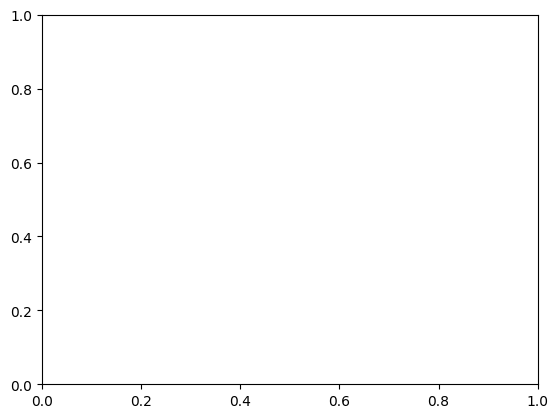

In [ ]:
df['is_impossible_travel'].plot(kind='')